# Power Balancing

In [3]:
import numpy as np
import matplotlib.pyplot as plt

We create a dummy series of values and introduce some steps.  Might want to play around with noise.

Also need to try on some different functions - e.g. linear.

In [75]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth


def generate_test_series(n=720, functype='linear', scale=1.):
    """Generates a test series of data"""
    x = np.arange(n)
    if functype == "linear":
        ybase = np.ones(n)
    elif functype == "sin":
        ybase = np.sin(np.radians(x))
    else:
        raise KeyError('Unknown functype')
    y = ybase + np.random.rand(n)
    y = add_offset(y, swath_bounds, offsets)
    return x, y


def add_offset(series, swath_bounds, offsets):
    """Adds an offset to each of the sub-swaths"""
    series_adj = np.zeros(series.shape)
    for swath_name, swath_region in swath_bounds.items():
        frs, lrs = swath_region['firstRangeSample'], swath_region['lastRangeSample']
        series_adj[frs:lrs] = series[frs:lrs] + offsets[swath_name]
    return series_adj


def plot_results(x, y, swath_bounds):
    fig, ax = plt.subplots(figsize=(12,7))
    ax.plot(x, y, 'o')
    ax.plot(x, smooth(y, 19))
    for _, b in swath_bounds.items():
        ax.axvline(b['lastRangeSample'], color='0.7')

In [57]:
swath_bounds = {
    'EW1': {
        'firstRangeSample': 0,
        'lastRangeSample': 100,
    },
    'EW2': {
        'firstRangeSample': 100,
        'lastRangeSample': 200,
    },
    'EW3': {
        'firstRangeSample': 200,
        'lastRangeSample': 400,
    },
    'EW4': {
        'firstRangeSample': 400,
        'lastRangeSample': 550,
    },
    'EW5': {
        'firstRangeSample': 550,
        'lastRangeSample': 720,
    },
}

offsets = {
    'EW1': -1.96883528,
    'EW2': -0.03128508,
    'EW3':  1.26749153,
    'EW4':  0.1734956,
    'EW5':  0.68036663,
}

In [83]:
x, y = generate_test_series(functype="sin")

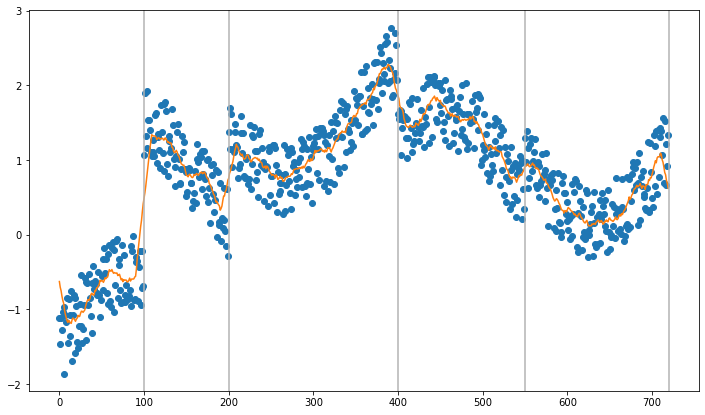

In [84]:
plot_results(x, y, swath_bounds)

In [85]:
left = 'EW1'
right = 'EW2'

left_bounds = swath_bounds[left]['lastRangeSample'] + np.array([-20, 0])
right_bounds = swath_bounds[right]['firstRangeSample'] + np.array([0,20])

left_power = np.mean(y[left_bounds[0]:left_bounds[1]])
right_power = np.mean(y[right_bounds[0]:right_bounds[1]])

new_offset = {
    'EW1': 0.,
    'EW2': left_power - right_power,
    'EW3': 0.,
    'EW4': 0.,
    'EW5': 0.
}

ynew = add_offset(y, swath_bounds, new_offset)

In [86]:
swath_names = list(swath_bounds.keys())
for left, right in zip(swath_names[:-1], swath_names[1:]):
    left_bounds = swath_bounds[left]['lastRangeSample'] + np.array([-20, 0])
    right_bounds = swath_bounds[right]['firstRangeSample'] + np.array([0,20])
    
    left_power = np.mean(y[left_bounds[0]:left_bounds[1]])
    right_power = np.mean(y[right_bounds[0]:right_bounds[1]])
    
    power_balance = left_power - right_power
    new_offset[right] = new_offset[left] + power_balance

print(new_offset)

{'EW1': 0.0, 'EW2': -1.8890914452093477, 'EW3': -2.726222372935852, 'EW4': -1.9202765089572396, 'EW5': -2.1505217313262115}


In [87]:
ynew = add_offset(y, swath_bounds, new_offset)

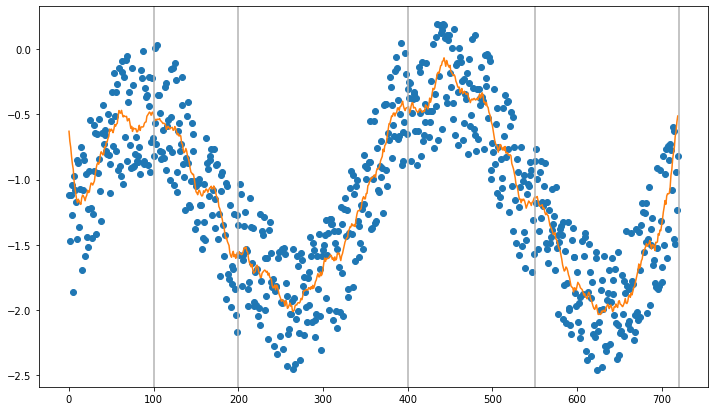

In [88]:
plot_results(x, ynew, swath_bounds)